<a href="https://colab.research.google.com/github/maizoh/Project_Shinshu/blob/main/Project_Shinshu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
pd.set_option('display.max_rows', None)
df=pd.read_csv("/content/Medical_Data/MedicalReportPubH_2024.csv",encoding="shift_jis")
df=pd.DataFrame(df)
df_selected=df.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]]
df_selected.to_pickle("/content/Medical_Data/df_selected_2024.pickle")

In [55]:
df = pd.read_pickle("/content/Medical_Data/df_selected_2024.pickle")
df.to_csv("/content/Medical_Data/df_test_2024.csv", index=False)

In [56]:
df = pd.read_pickle("/content/Medical_Data/df_selected_2024.pickle")
df_med=df[df["概要"]=="薬剤"]
df_med["発生時間帯"].value_counts()

,count
発生時間帯,
8:00〜9:59,851
10:00〜11:59,715
12:00〜13:59,612
16:00〜17:59,578
14:00〜15:59,562
18:00〜19:59,483
20:00〜21:59,387
6:00〜7:59,261
22:00〜23:59,179


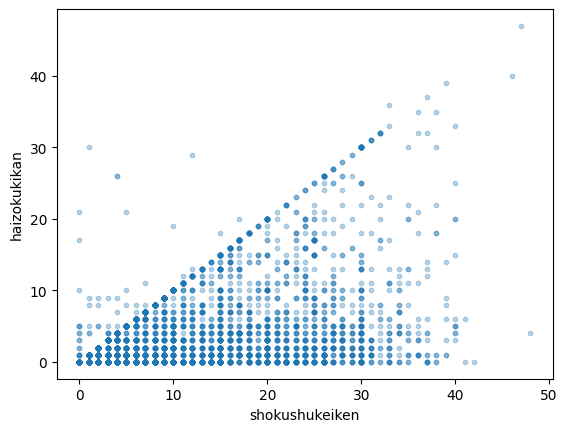

<Figure size 600x100 with 0 Axes>

In [57]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()

plt.figure(figsize=(6,1))

ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

df["当事者職種経験（年数）_1"]=df["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df['当事者部署配属期間（年数）_1']=df['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)
x=df["当事者職種経験（年数）_1"]
y=df['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.3)

plt.show()

y=xは配属機関が１か所だけってことだから、多くなるのは必然？
y=x越すはずないのに越してるやつらいるので洗浄する

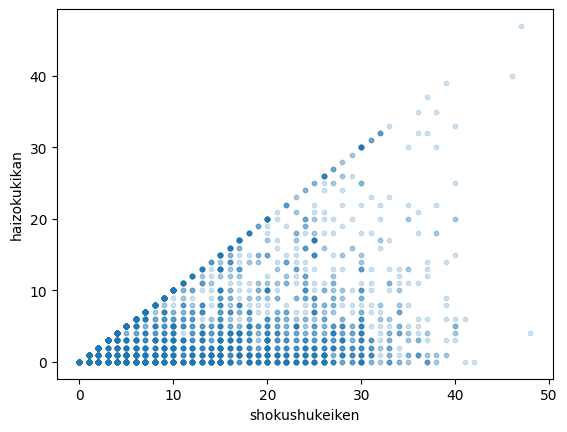

<Figure size 600x100 with 0 Axes>

In [58]:
df_clean=df[df['当事者職種経験（年数）_1']>=df['当事者部署配属期間（年数）_1']].copy()
fig,ax=plt.subplots()

plt.figure(figsize=(6,1))

ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

df_clean["当事者職種経験（年数）_1"]=df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1']=df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)
x=df_clean["当事者職種経験（年数）_1"]
y=df_clean['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.2)

plt.show()

20から30年あたりが顕著だが、こんだけのベテランでも配属期間が短いほどミスしやすくなっている感じがある。(下のほうが濃いことから)

当事者部署配属期間（年数）_1
0     23.592493
2     11.796247
1     11.528150
10     9.651475
3      9.115282
5      6.568365
4      5.227882
13     3.619303
6      3.217158
11     3.083110
7      3.083110
8      2.949062
12     2.278820
15     2.010724
9      1.340483
14     0.938338
Name: proportion, dtype: float64


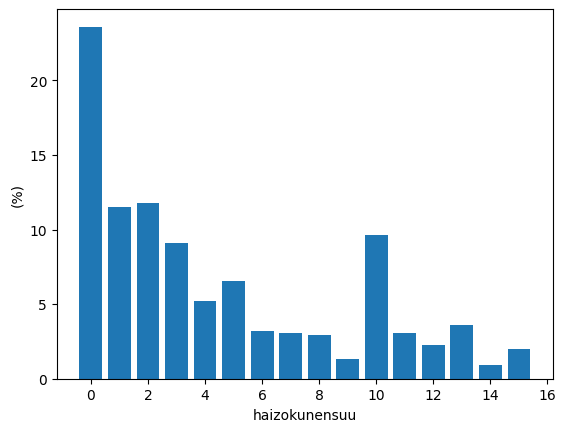

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= 10) & (df_clean["当事者職種経験（年数）_1"] <= 15)]

# 2. 比率の集計（ここで比率データを作る）
assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100

# 3. グラフ描画の設定
fig, ax = plt.subplots()

# x軸には「年数（index）」、y軸には「比率（値）」を渡す
x = assignment_ratio.index
y = assignment_ratio.values

ax.bar(x, y)


ax.set_xlabel("haizokunensuu")
ax.set_ylabel("(%)")


print(assignment_ratio)
plt.show()

In [60]:
assignment_ratio.head()

,proportion
当事者部署配属期間（年数）_1,
0,23.592493
2,11.796247
1,11.528150
10,9.651475
3,9.115282


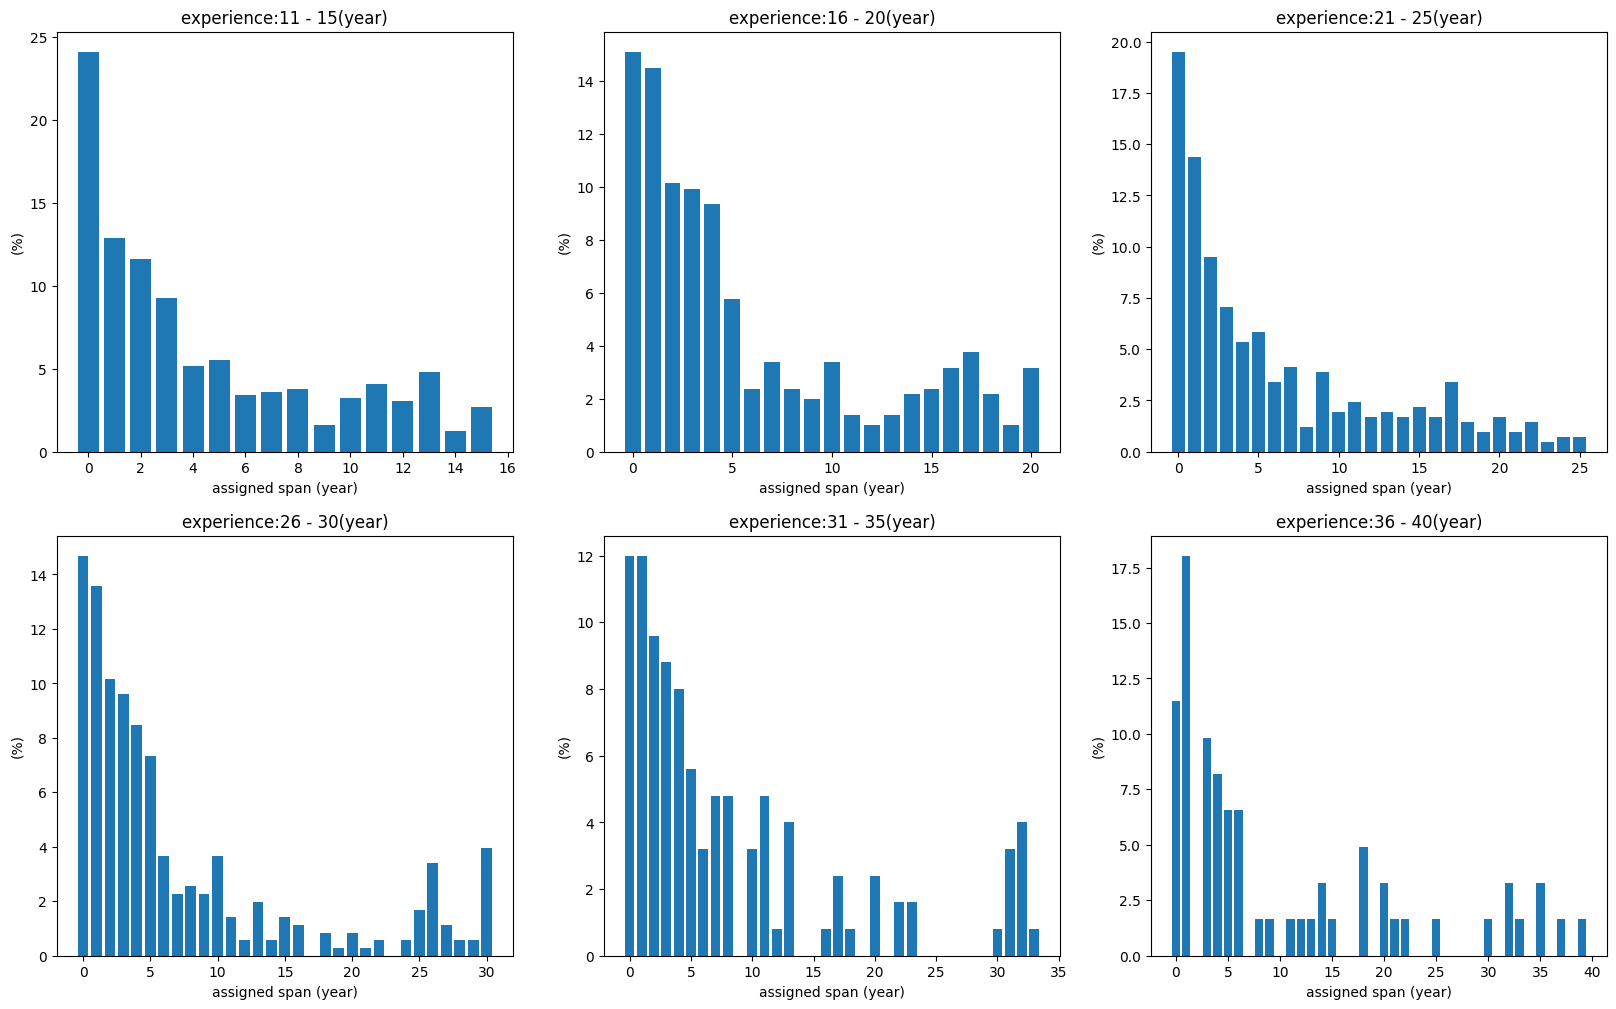

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

# 3. グラフ描画の設定
fig, ax = plt.subplots(2,3,figsize=(20,12))
#(2,3)にしたことでaxがndarrayオブジェクトになっているため、ax.barが使えない。書くべき場所が6か所あるのにどこに書くか指定してないからバグる。
ax=ax.flatten()

for i,year in enumerate(range(11,41,5)):
#enumerateはyearが取り出しているものに対してiがナンバリングしていく感じ


  filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= year) & (df_clean["当事者職種経験（年数）_1"] <= year+4)]

  # 2. 比率の集計（ここで比率データを作る）
  assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100



  # x軸には「年数（index）」、y軸には「比率（値）」を渡す
  x = assignment_ratio.index
  y = assignment_ratio.values

  ax[i].bar(x,y)


  ax[i].set_xlabel("assigned span (year)")
  ax[i].set_ylabel("(%)")

  a=f"experience:{year} - {year+4}(year)"
  ax[i].set_title(a)

plt.show()


1.  fig, ax = plt.subplots(2,3)→[[ax00, ax01, ax02],[ax10, ax11, ax12]]という構造
2.  ax.flatten()で１次元構造に変換→[ax00, ax01, ax02, ax10, ax11, ax12]
　　アクセスがax[2]などで可能に






In [62]:
df=df_clean

In [64]:
df_instant=df[df['概要']=="薬剤"]
df_medicine_com=df_instant[df['発生要因_環境・設備機器']=="コンピュータシステム"]
df_medicine_com.shape
#med_comは薬剤かつコンピューターが要因
df_medicine_com["事例の内容"].value_counts()

/tmp/ipykernel_2776/575164429.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_medicine_com=df_instant[df['発生要因_環境・設備機器']=="コンピュータシステム"]


,count
事例の内容,
無投薬,31
処方忘れ,20
その他の処方に関する内容,20
過剰投与,12
その他の与薬準備に関する内容,12
処方量間違い,11
その他の与薬に関する内容,10
薬剤間違い,9
その他の調剤に関する内容,9


In [65]:
df_medicine_com['事例の内容'].unique()

array(['その他の処方に関する内容', '過剰投与', '薬剤間違い', 'その他の調剤に関する内容', '調剤忘れ', '処方薬剤間違い',
       '投与速度速すぎ', 'その他の与薬準備に関する内容', '処方量間違い', '過少与薬準備', '禁忌薬剤の投与',
       '投与方法間違い', '無投薬', '重複処方', '過少投与', 'その他の製剤管理に関する内容', '分包間違い',
       '数量間違い', '処方箋・注射箋鑑査間違い', '患者間違い', '処方忘れ', '投与方法処方間違い',
       'その他の与薬に関する内容', '薬剤取り違え調剤', '重複投与', '与薬時間・日付間違い', '禁忌薬剤の処方',
       '禁忌薬剤の与薬', '対象患者処方間違い', '処方遅延', '投与時間・日付間違い', '単位間違い調剤', '過剰与薬準備',
       '処方単位間違い', '重複与薬', '秤量間違い調剤', '薬袋・ボトルの記載間違い'], dtype=object)

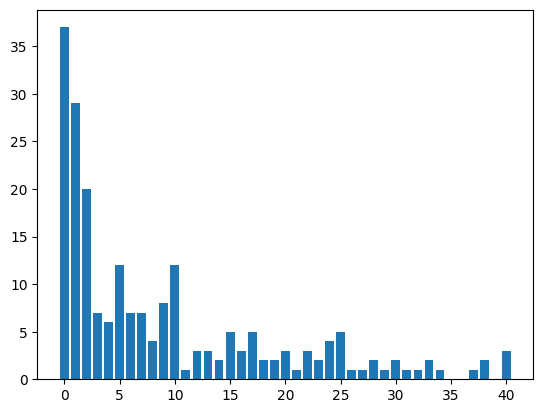

In [66]:
fig,ax=plt.subplots()

x=df_medicine_com['当事者職種経験（年数）_1'].value_counts().index
y=df_medicine_com["当事者職種経験（年数）_1"].value_counts().values

ax.bar(x,y)

plt.show()

コンピューターだからって年齢高いほどミスるわけじゃなさげ

In [67]:
df_medicine_com.shape

(211, 15)

**こっからLLM導入するぞ**

In [ ]:
import google.generativeai as genai
import pandas as pd
import time

# 1. APIキー設定
GOOGLE_API_KEY = "" # 自分のキーを入れてね
genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel(model_name='models/gemini-2.5-flash')

# 2. プロンプト
PROMPT_TEMPLATE = """
あなたは医療安全の専門家です。以下の「ヒヤリハット事例」を読み、最も合致するジャンルを1つ選んでください。

【選択肢】
1. 薬の取り違え（薬剤間違い、処方薬剤間違いなど）
2. 量・数の間違い（過剰投与、過少投与、重複、単位間違いなど）
3. 患者の取り違え（対象患者間違いなど）
4. 方法・タイミング（投与方法、投与速度、時間・日付間違いなど）
5. 抜け・忘れ（処方忘れ、調剤忘れ、無投薬、処方遅延など）
6. その他

【事例】
{}

【出力形式】
ジャンル：[選択肢の文字列]
理由：[理由を20文字以内で]
"""

# 3. 分類処理
def analyze_medicine_data(df):
    total_rows = len(df)

    if total_rows > 221:
        print(f"🚨 エラー: 実際のデータ数が {total_rows} 件あります。処理を中断します。")
        return None

    genres = []
    reasons = []

    print(f"分析開始: 実際のデータ数は {total_rows} 件です。")
    print("※無料枠の制限に合わせてゆっくり進むので、終わるまで約45分かかります☕")

    for count, (idx, row) in enumerate(df.iterrows(), 1):
        text = str(row['事例の内容.1'])
        genre, reason = "その他", "判定なし"

        # ★ リトライ機能（最大3回までやり直す）
        max_retries = 3
        for attempt in range(max_retries):
            try:
                response = model.generate_content(PROMPT_TEMPLATE.format(text))
                res_text = response.text

                genre = next((line.split('：')[1] for line in res_text.split('\n') if 'ジャンル：' in line), "その他")
                reason = next((line.split('：')[1] for line in res_text.split('\n') if '理由：' in line), "判定なし")
                break # 成功したらループを抜ける

            except Exception as e:
                error_msg = str(e)
                # 429（制限エラー）が出たら長めに休んで再トライ
                if '429' in error_msg or 'Quota' in error_msg:
                    print(f"⚠️ {count}件目で制限待ち... 15秒休んで再トライします ({attempt+1}/{max_retries}回目)")
                    time.sleep(15)
                else:
                    print(f"❌ {count}件目で別のエラー発生: {error_msg[:30]}")
                    genre, reason = "エラー", error_msg[:20]
                    break

        genres.append(genre)
        reasons.append(reason)

        if count % 10 == 0:
            print(f"進捗: {count} / {total_rows} 件完了...")

        # ★ 制限に引っかからないように、毎回12.5秒待つ
        time.sleep(12.5)

    df_result = df.copy()
    df_result['分類ジャンル'] = genres
    df_result['分類理由'] = reasons
    return df_result

# 4. 実行
analyzed_df = analyze_medicine_data(df_medicine_com)

# 5. 保存
if analyzed_df is not None:
    analyzed_df.to_csv('df_medicine_analyzed.csv', index=False, encoding='utf-8-sig')
    print("分析完了！ 'df_medicine_analyzed.csv' を確認してね。")